# **2.1.3 - Bài tập thực hành 1: Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic**

## **1. Tải và khám phá dữ liệu**

In [2]:
import pandas as pd

# Đọc dữ liệu Titanic
data = pd.read_csv('dataset/titanic.csv')  # thay bằng đường dẫn thực tế nếu cần
print(data.head())
print(data.info())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

## **2. Tiền xử lý dữ liệu**

In [3]:
# Xóa các cột không cần thiết
data = data.drop(columns=['Name', 'Ticket', 'Cabin'])

# Xử lý giá trị thiếu
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Mã hóa biến phân loại
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

# Tách đặc trưng và nhãn
X = data.drop('Survived', axis=1)
y = data['Survived']


C:\Users\ACER\AppData\Local\Temp\ipykernel_23168\1104601313.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_23168\1104601313.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

## **3. Chia tập huấn luyện và kiểm tra**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **4. Huấn luyện mô hình Cây quyết định và Rừng cây**

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Cây quyết định
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Rừng cây
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## **5. Đánh giá mô hình**

In [6]:
from sklearn.metrics import accuracy_score, classification_report

# Cây quyết định
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Rừng cây
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Decision Tree Accuracy: 0.7206703910614525
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.66      0.68      0.67        74

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179

Random Forest Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



**Nhận xét:** Mô hình Random Forest cho kết quả tốt hơn rõ rệt so với Cây quyết định: độ chính xác tăng từ 72% lên 82%, và các chỉ số precision, recall, f1-score đều cải thiện. Điều này cho thấy rừng cây xử lý dữ liệu phức tạp và giảm overfitting hiệu quả hơn.

## **6. Trực quan hóa cây quyết định**

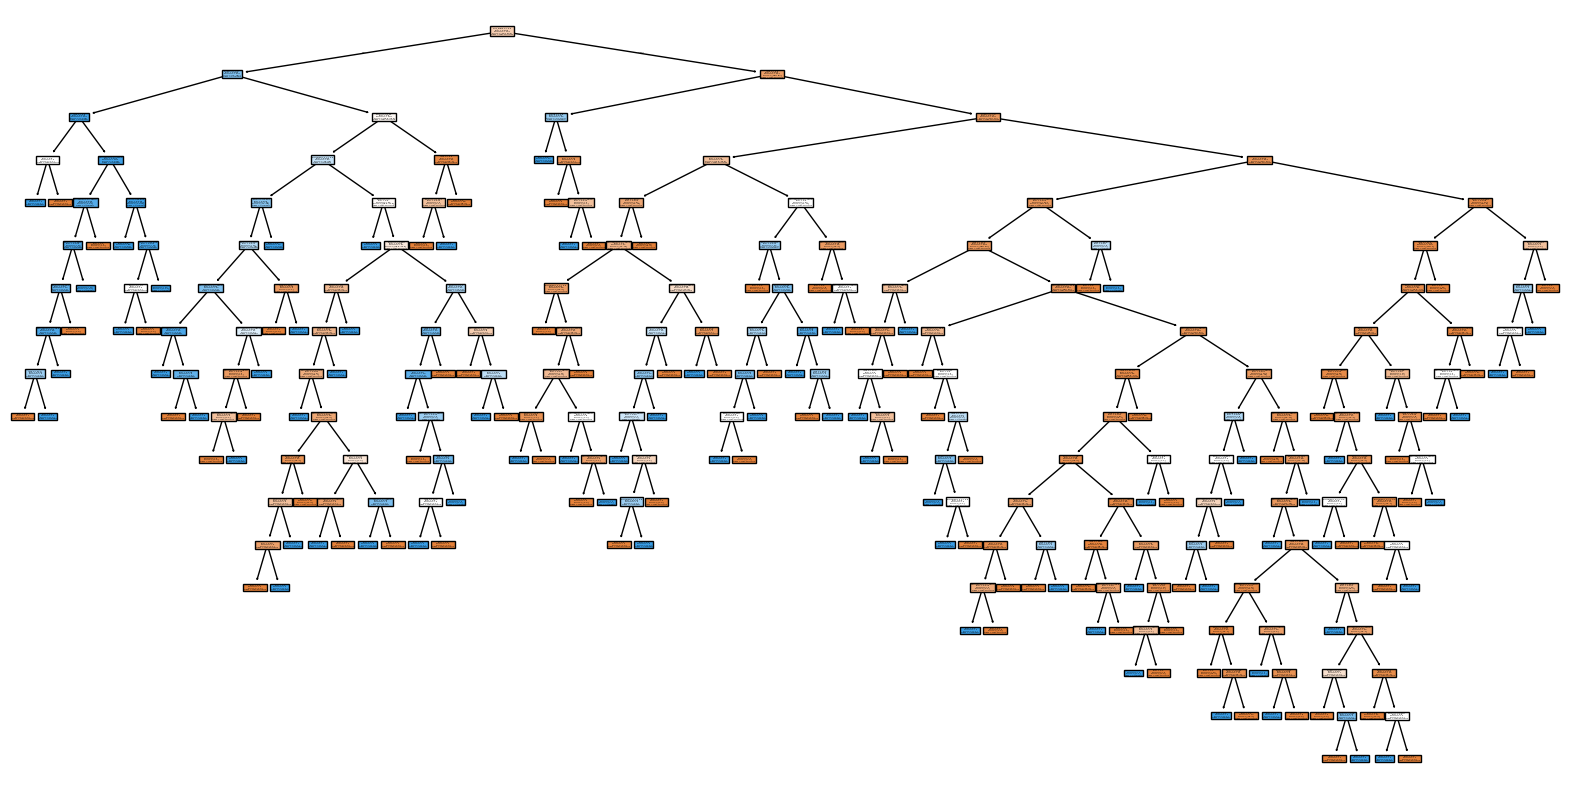

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()


**Nhận xét:** Cây quyết định cho độ chính xác 72%, nhưng Rừng cây vượt trội với 82%, cho thấy mô hình ensemble giúp cải thiện hiệu suất rõ rệt. Rừng cây phân loại tốt hơn cả hai lớp, đặc biệt là giảm sai sót khi dự đoán người sống sót.